# FScanpy：完整序列 PRF 预测结果解读

本教程使用新版 **PyTorch 短模型 HistGradientBoosting 与长模型 BiLSTM-CNN**，参考原始样本的完整结果选择案例：参考区域相对突出、峰高相近但局部支持不同，以及多个强信号区域仍存在歧义。

每个案例均扫描**完整 CDS**。先查看全序列曲线，再检查局部区域。

可同时参考[旧版模型执行结果](predict_sample_legacy_zh.ipynb)和[历史保存结果归档](predict_sample_legacy_saved_zh.ipynb)。归档保留全部六张原图，可供阅读对照。

[English](predict_sample.ipynb) | **中文**

## 1. 加载模型和示例序列

使用已安装 FScanpy、pandas 和 matplotlib 的 Python 内核，将随附的 `data` 文件夹与 notebook 一起保留。下面的模型检查可避免把旧版双树模型的输出误当成新版 PyTorch 结果。

新版沿用旧版的 `plot_prf_prediction()` 和 `predict_prf()` 接口，函数名、参数名和返回结果结构保持一致。图内保留通用英文标签，便于中英文逐图对照。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from FScanpy import PRFPredictor, predict_prf, plot_prf_prediction

torch.set_num_threads(1)
predictor = PRFPredictor()
assert isinstance(predictor.long_model, torch.nn.Module), "本教程需要新版 PyTorch 长模型。"

data_folder = Path("data")
if not data_folder.is_dir():
    data_folder = Path("tutorial") / "data"
examples = pd.read_csv(data_folder / "predict_sample_examples.csv")
records = examples.set_index("Sequence_ID")
display(examples.drop(columns="Full_Sequence"))

,Sequence_ID,DNA_seqid,Genome,Product,length,reference_codon_start_0based
0,0,JN698994.1,Mycobacterium phage DS6A,tail assembly chaperone,780,297
1,1,MN234184.1,Mycobacterium phage IdentityCrisis,tail assembly chaperone,705,309
2,2,Efeko,Microbacterium phage Efeko,tail assembly chaperone,423,249
3,3,Hiyaa,Streptomyces phage Hiyaa,tail assembly chaperone,759,543
4,4,NC_003919.1,Xanthomonas citri pv. citri str. 306,IS3 family transposase,1089,252


## 2. 阅读与原版一致的图形

全序列图保留原版结构：**上方两个粗红色热图，下方黑色柱状图**。局部比较也采用相同结构。

- **FS site (predicted candidates)**：标记通过显示过滤且集成分数至少为 0.8 的预测候选。它来自模型输出，并非实验验证的真实注释。原绘图方法会扩大标记宽度以便观察。
- **Prediction**：以红色热图显示过滤后的集成分数，其标记同样具有显示宽度。
- **柱状图**：显示每个扫描位置经同一显示过滤后的分数。绿色虚线单独标记参考密码子的起点，不由热图推断真实位置。

每 3 nt 扫描一次，短模型内部门控为 0.1，两个模型的显示阈值均为 0.2。主体固定 `ensemble_weight=0.6`，与旧教程多数示例相同：`ensemble = 0.6 × short + 0.4 × long`。API 默认权重为 0.4。

`window_size` 表示每隔多少个核苷酸扫描一次：3 为每 3 nt 一次，1 为逐位扫描。它控制扫描间隔；模型输入长度仍为 33 bp 和 399 bp。增大扫描间隔会减少预测次数，用于提高长序列或全基因组预测效率，同时可能跳过较窄的信号区域。

In [2]:
PARAMS = dict(window_size=3, short_threshold=0.2, long_threshold=0.2, ensemble_weight=0.6)
results_by_sequence = {}
figures_by_sequence = {}

def plot_example(sequence_id):
    row = records.loc[sequence_id]
    result, figure = plot_prf_prediction(
        sequence=str(row.Full_Sequence), **PARAMS,
        title=f"Sequence {sequence_id} | complete CDS",
        figsize=(14, 8), dpi=120,
    )
    # 保留原版热图及柱状图，并加粗热图面板。
    grid = figure.axes[0].get_subplotspec().get_gridspec()
    grid.set_height_ratios([0.35, 0.35, 2.8])
    figure.axes[0].set_title("FS site (predicted candidates)", fontsize=10)
    figure.axes[1].set_title("Prediction", fontsize=10)
    reference = int(row.reference_codon_start_0based)
    for axis in figure.axes:
        axis.axvline(reference, color="#009E73", linestyle="--", linewidth=1.2)
    figure.axes[2].set_xlabel("Codon start (0-based nt)")
    figure.axes[2].set_ylabel("Filtered ensemble score")
    figure.axes[2].plot([], [], color="#009E73", linestyle="--", label=f"Reference {reference}")
    figure.axes[2].legend(loc="upper right", fontsize=9)
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    results_by_sequence[sequence_id] = result
    figures_by_sequence[sequence_id] = figure
    return result, figure

def visible_scores(result):
    mask = (result.Short_Probability >= 0.2) & (result.Long_Probability >= 0.2)
    return result.Ensemble_Probability.where(mask, 0)

def compare_regions(result, centers):
    """在等宽局部窗口中比较已有密码子预测。"""
    scores = visible_scores(result)
    figure = plt.figure(figsize=(14, 5.3))
    grid = figure.add_gridspec(3, len(centers), height_ratios=[0.35,0.35,2.8], hspace=0.5)
    summary = []
    for column, (label, center) in enumerate(centers):
        local = (result.Position-center).abs() <= 15
        count = int((scores[local] >= 0.7).sum())
        summary.append(dict(region=label, center=center, high_score_codons=count,
                            scanned_codons=int(local.sum()), local_max=float(scores[local].max())))
        # 局部图同样保留候选条带热图和分数热图。
        candidate_strip = np.zeros((1,33))
        score_strip = np.zeros((1,33))
        for position, score in zip(result.loc[local,"Position"], scores[local]):
            index = int(position-center)+16
            score_strip[0,index] = score
            if score >= 0.8:
                candidate_strip[0,max(0,index-1):min(33,index+2)] = 1
        top = figure.add_subplot(grid[0,column])
        middle = figure.add_subplot(grid[1,column])
        for heatmap, strip in [(top,candidate_strip),(middle,score_strip)]:
            heatmap.imshow(strip,cmap="Reds",aspect="auto",vmin=0,vmax=1,
                           interpolation="nearest",extent=(-16.5,16.5,0,1))
            heatmap.set_xticks([]); heatmap.set_yticks([])
        top.set_title(f"{label}: {center}\nFS site (predicted candidates)",fontsize=9)
        middle.set_title("Prediction",fontsize=9)
        axis = figure.add_subplot(grid[2,column])
        axis.bar(result.loc[local, "Position"]-center, scores[local], color="black", alpha=0.6, width=1)
        axis.axhline(0.7, color="gray", linestyle=":", linewidth=1)
        axis.set(xlim=(-16.5,16.5), ylim=(0,1.03), xlabel="Offset from center (nt)",
                 title=f"Score >= 0.7: {count} codons")
        axis.set_xticks([-15,0,15]); axis.grid(axis="y", alpha=0.2)
        if column==0:axis.set_ylabel("Filtered ensemble score")
    figure.tight_layout()
    return pd.DataFrame(summary), figure

## 3. 参考区域相对突出

这条 SEAPHAGES CDS 长 780 nt，参考起点为 **297**。**300** 附近的峰约为 **0.963**，远处最强峰在 **9** 附近，约为 **0.891**。参考位置 ±15 nt 内有 5 个密码子的显示分数至少为 0.7。

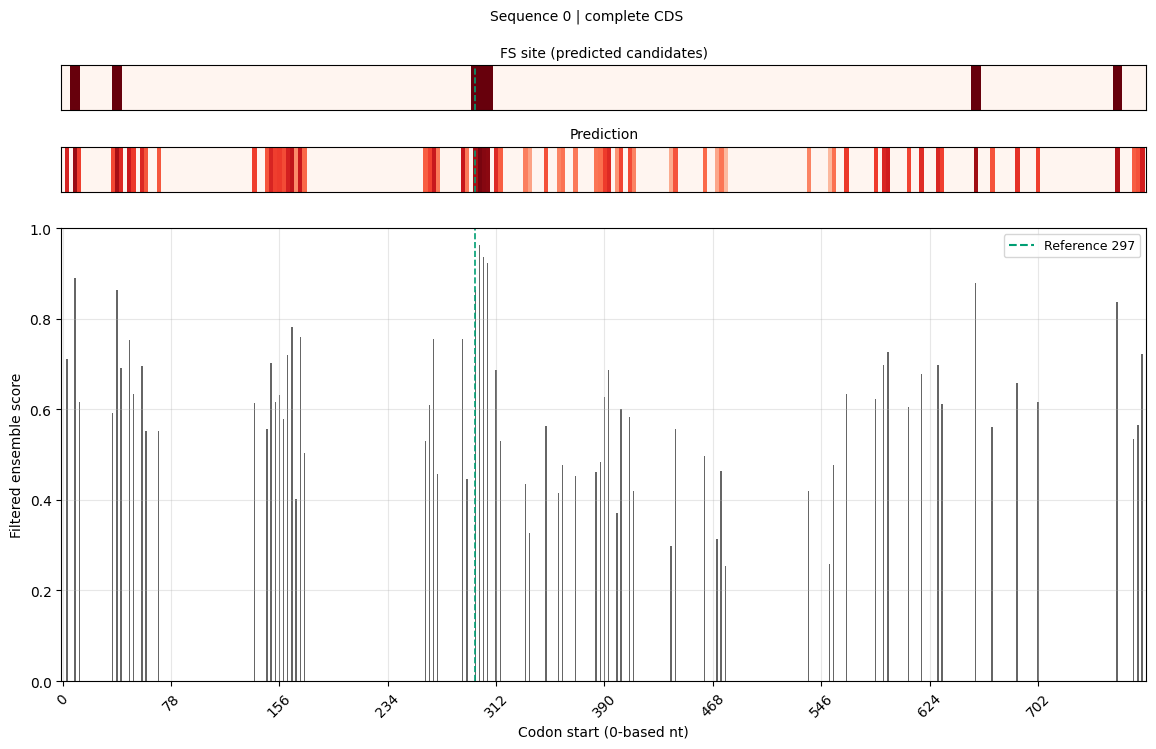

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,297,5,11,0.963053
1,Competitor,9,2,9,0.890966
2,Competitor,657,1,11,0.878959
3,Competitor,759,1,11,0.836836


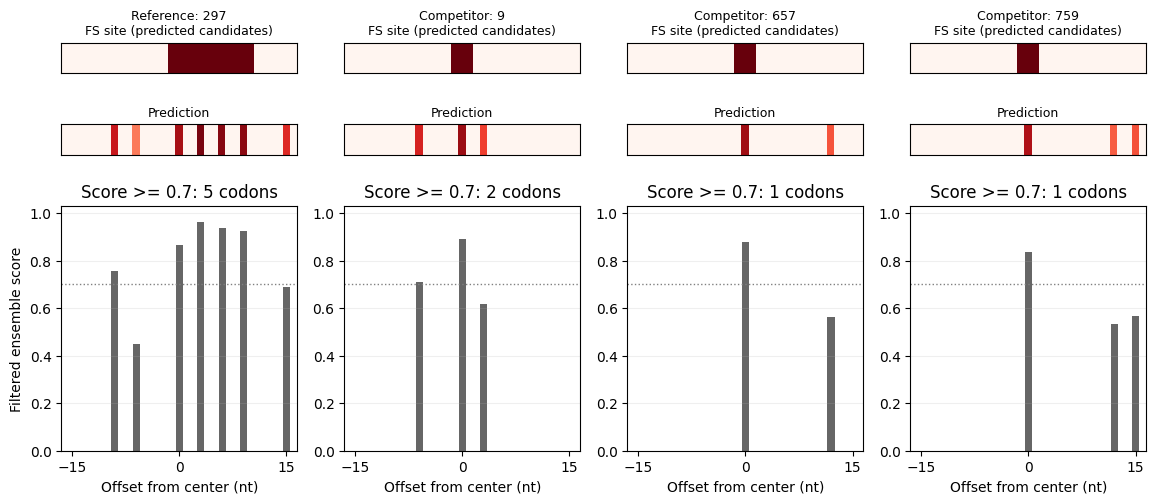

In [3]:
result, figure = plot_example(0)
plt.show()
local_summary, figure = compare_regions(result, [("Reference",297), ("Competitor",9), ("Competitor",657), ("Competitor",759)])
display(local_summary)
plt.show()

## 4. 峰高相近，但局部支持不同

这条 SEAPHAGES CDS 长 705 nt，参考起点为 **309**。附近 **312** 的峰约为 **0.9755**，远处 **645** 的峰约为 **0.9761**。仅按峰高会优先选择远处候选。

在等宽的 ±15 nt 窗口中，参考区域有 **6** 个显示分数至少为 0.7 的密码子，645 区域只有 **1** 个，252 区域有 **2** 个；48 附近另有 **5** 个。参考区域的集中信号可提供支持，但不能确认 PRF 事件，也不能排除其他区域。这比仅挑选参考峰排名靠前的样本，更符合旧版 Sequence 1 展示的情形。

相邻窗口高度重叠，分数具有相关性；密集峰群不代表多次独立验证。645 的 399 bp 窗口还需要右端补 N，而参考 309 和竞争区域 252 具有完整上下文。

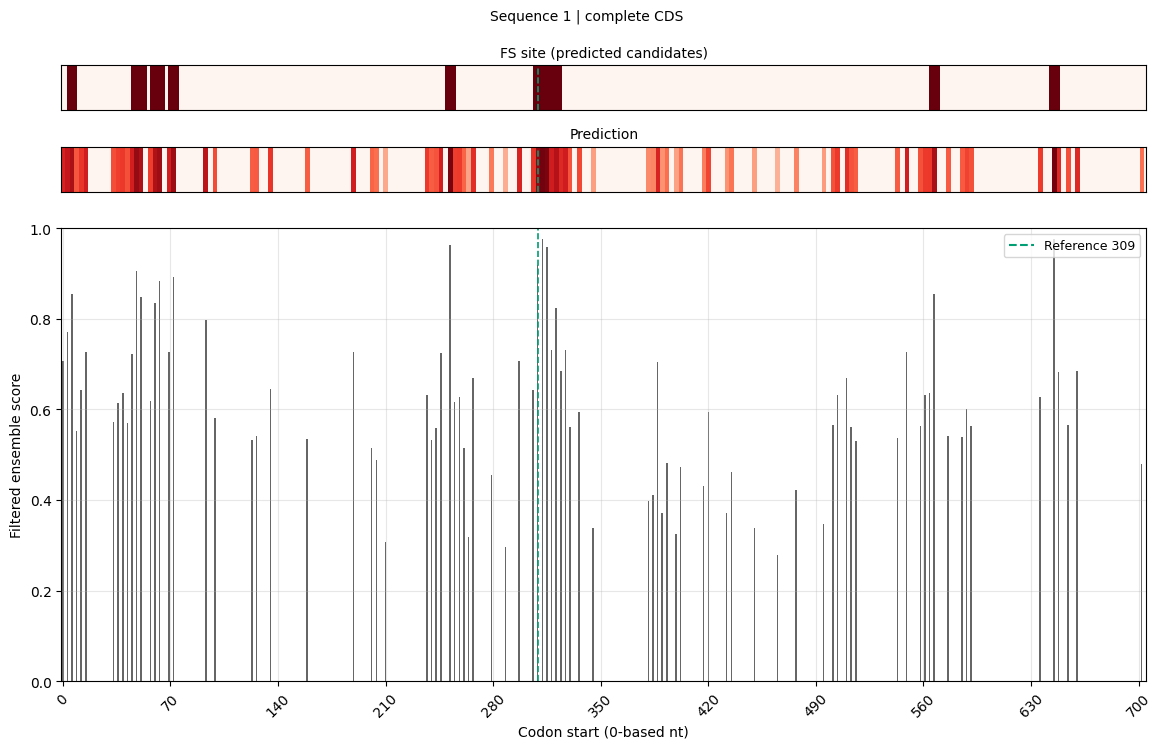

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,309,6,11,0.975485
1,Competitor,645,1,11,0.976088
2,Competitor,252,2,11,0.962624
3,Competitor,48,5,11,0.905637


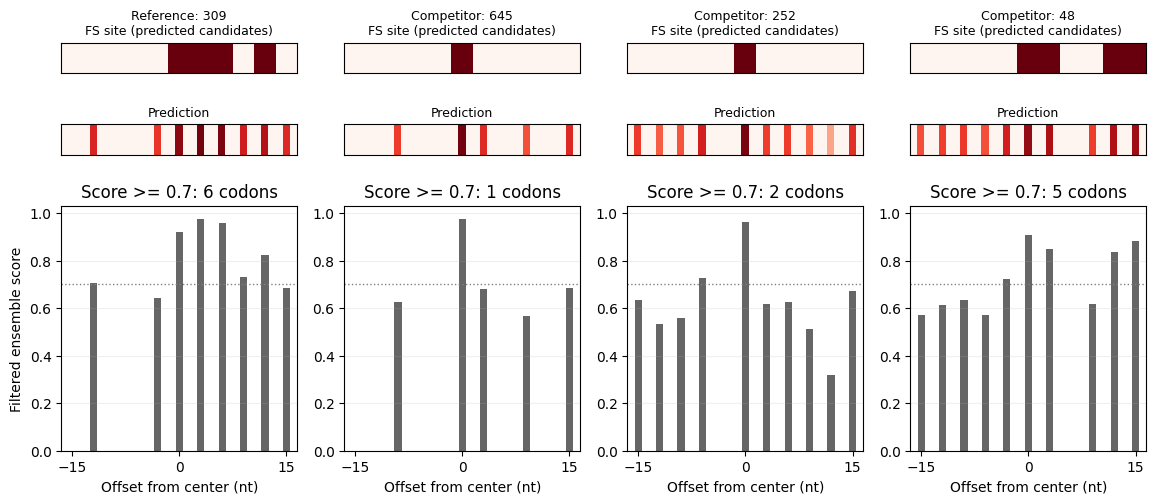

In [4]:
result, figure = plot_example(1)
plt.show()
local_summary, figure = compare_regions(result, [("Reference",309), ("Competitor",645), ("Competitor",252), ("Competitor",48)])
display(local_summary)
plt.show()

## 5. 短 CDS 的峰群密度比较

这条 SEAPHAGES CDS 长 423 nt，与旧版 429 nt 样本长度相近。参考起点为 **249**，其峰约为 **0.9995**；远处 **330** 的峰也达到约 **0.9949**。

参考位置 ±15 nt 内有 **10** 个显示分数至少为 0.7 的密码子，330 附近只有 **1** 个，6 附近有 **2** 个。即使完整曲线存在很强的背景峰，局部对比仍能提供信息。但此例展示的是短序列中的密集区域，并非旧版“几乎只有一个明显峰”的复现。参考位置的 399 bp 窗口需要右端补 N。

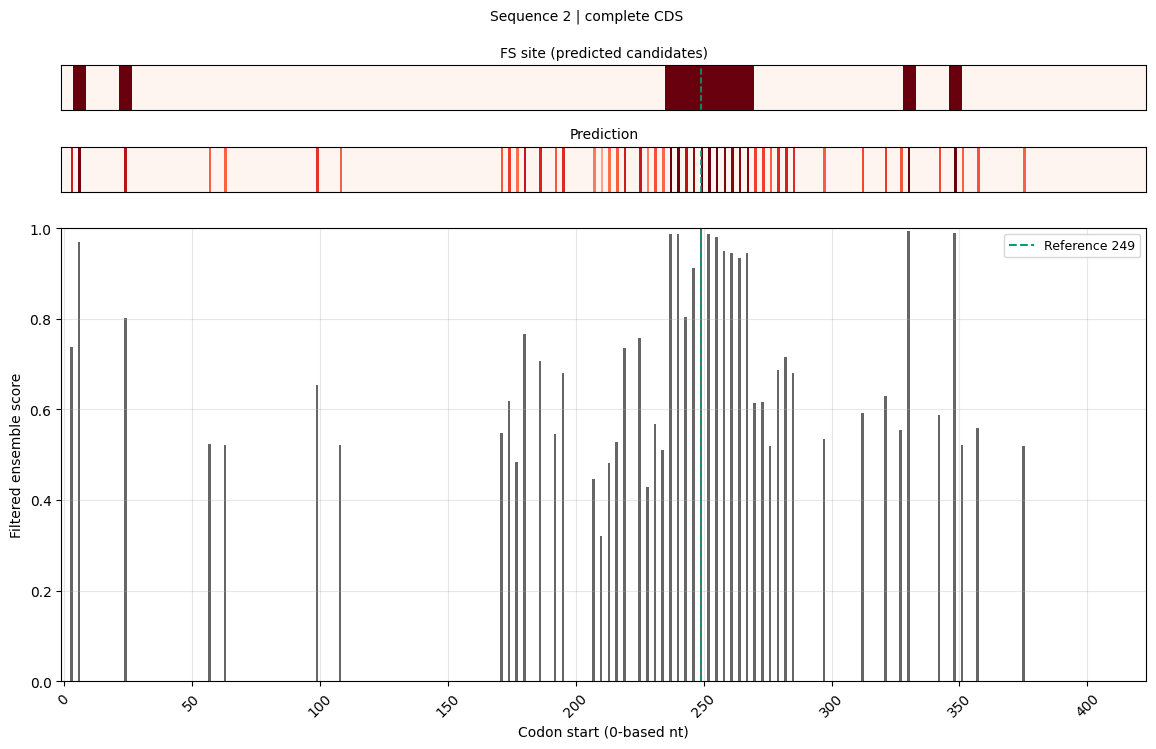

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,249,10,11,0.999480
1,Competitor,330,1,11,0.994856
2,Competitor,6,2,8,0.969400
3,Competitor,180,2,11,0.765846


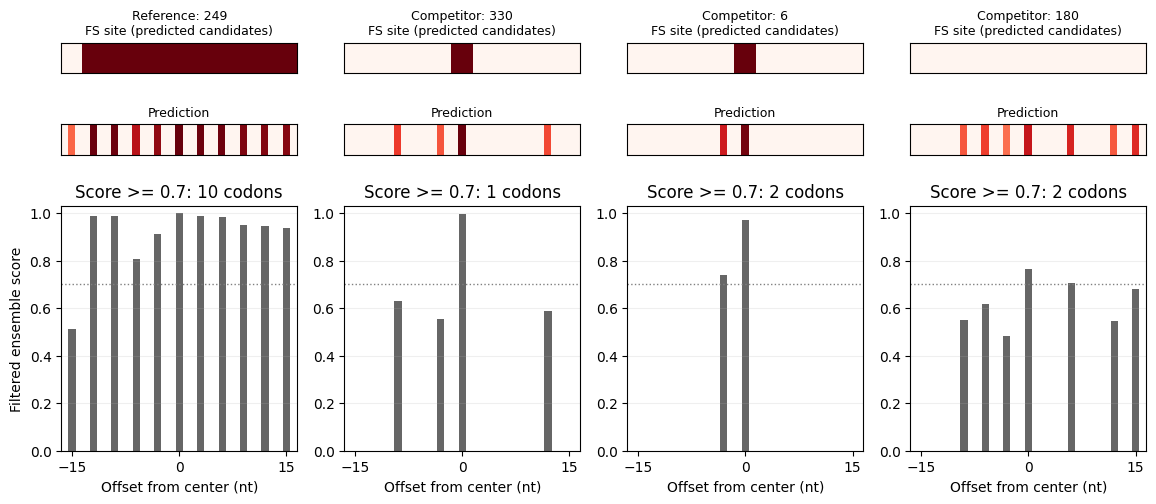

In [5]:
result, figure = plot_example(2)
plt.show()
local_summary, figure = compare_regions(result, [("Reference",249), ("Competitor",330), ("Competitor",6), ("Competitor",180)])
display(local_summary)
plt.show()

## 6. 多个强信号区域仍有歧义

这条 SEAPHAGES CDS 长 759 nt，参考起点为 **543**，其分数约为 **0.978**；**24、672、72** 附近的竞争峰分别约为 **0.998、0.997、0.996**。

参考位置 ±15 nt 内有 **5** 个显示分数至少为 0.7 的密码子，三个竞争区域分别有 **3、4、7** 个。峰高和局部密度均不能给出唯一答案。这对应旧版 Sequence 14 的情形，需要结合其他生物学证据或实验验证。

最强的三个竞争区域在构建 399 bp 窗口时都需要端部补 N，而参考 543 具有完整上下文。这个差异值得考虑，但不能自动把边界峰判为假阳性。

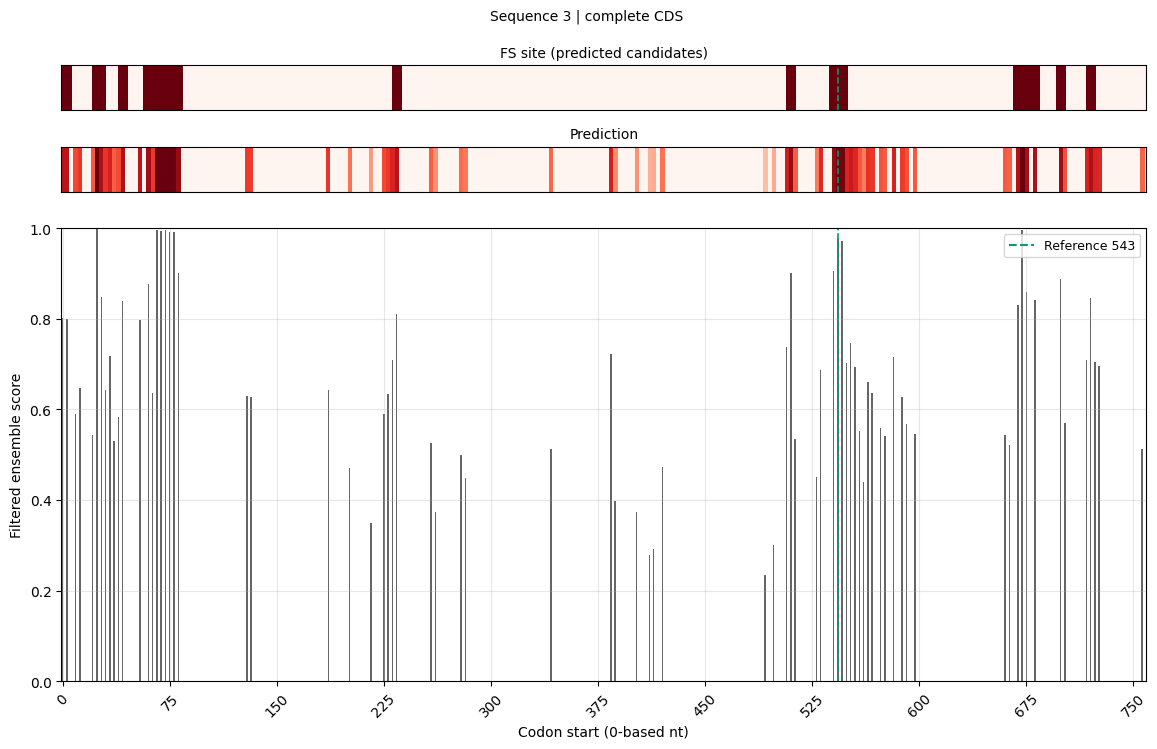

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,543,5,11,0.978280
1,Competitor,24,3,11,0.997771
2,Competitor,672,4,11,0.997125
3,Competitor,72,7,11,0.995848


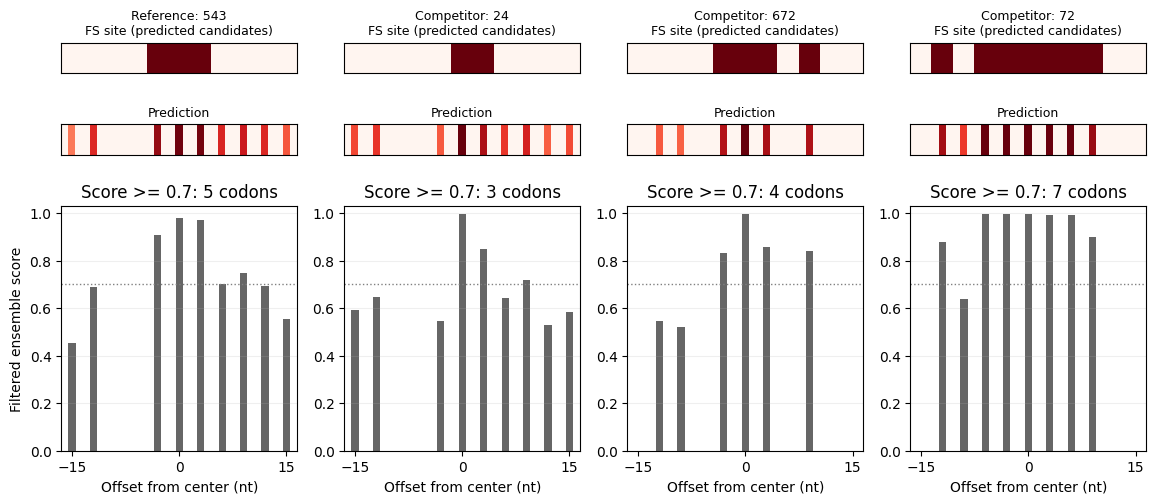

In [6]:
result, figure = plot_example(3)
plt.show()
local_summary, figure = compare_regions(result, [("Reference",543), ("Competitor",24), ("Competitor",672), ("Competitor",72)])
display(local_summary)
plt.show()

## 7. 可选的低背景教学补充

这条 FSDB CDS 长 1089 nt，在当前权重下，约 14% 的扫描位置通过显示过滤，约 2.2% 的位置得分至少为 0.7。

参考起点为 **252**，附近最高峰在 **258**，约为 **0.970**，有 6 nt 偏差。远处 **912** 仍有约 **0.909** 的峰，711 和 819 附近也有候选。

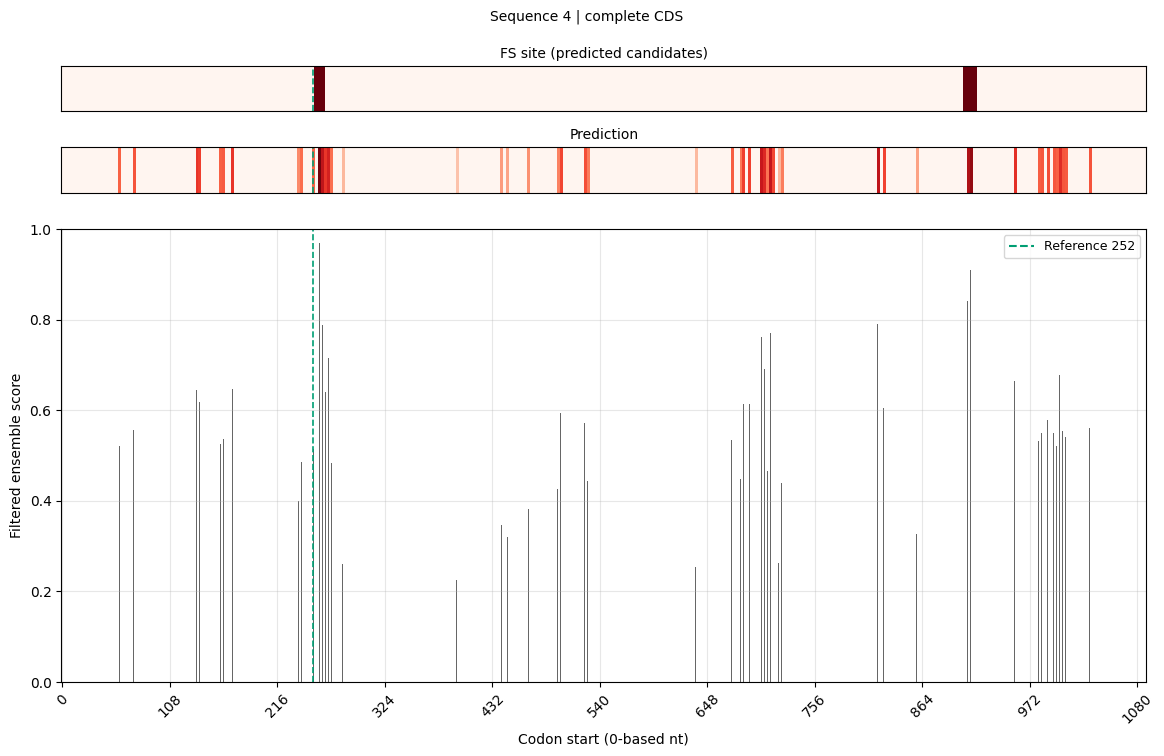

,region,center,high_score_codons,scanned_codons,local_max
0,Reference,252,3,11,0.969608
1,Competitor,912,2,11,0.909088
2,Competitor,819,1,11,0.789247
3,Competitor,711,2,11,0.770667


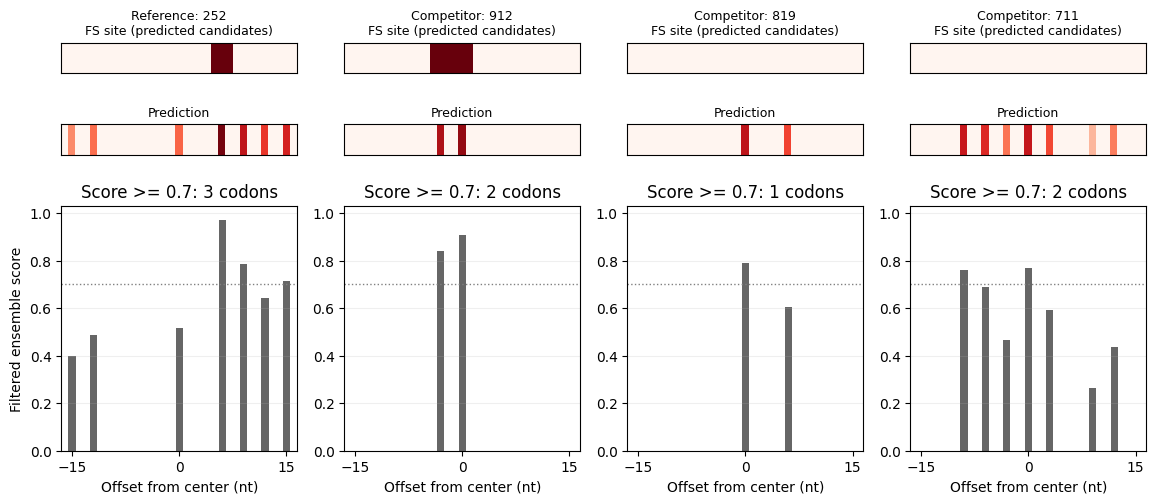

In [7]:
result, figure = plot_example(4)
plt.show()
local_summary, figure = compare_regions(result, [("Reference",252), ("Competitor",912), ("Competitor",819), ("Competitor",711)])
display(local_summary)
plt.show()

## 8. 使用扫描间隔调整预测效率

`window_size` 是扫描间隔，指定每隔多少个核苷酸调用一次预测。对长序列或全基因组进行初步扫描时，可以增大间隔以减少计算；对候选区域进行检查时，可以减小间隔以得到更密集的输出。

下面比较每 3 nt、每 6 nt 和逐位扫描的输出行数。模型的输入长度保持不变。当前实现提取输入时仍对齐到密码子起点，因此逐位扫描的相邻三个位置可能使用相同窗口；这些重复分数不代表额外的独立证据。

In [8]:
coarse = results_by_sequence[1]
sequence = str(records.loc[1, "Full_Sequence"])
fine = predict_prf(sequence=sequence, window_size=1,
                   short_threshold=0.1, ensemble_weight=0.6)
fast = predict_prf(sequence=sequence, window_size=6,
                   short_threshold=0.1, ensemble_weight=0.6)
probability_columns = ["Short_Probability", "Long_Probability", "Ensemble_Probability"]
snapped = (fine.Position//3*3).to_numpy()
expected = coarse.set_index("Position").loc[snapped, probability_columns].to_numpy()
np.testing.assert_allclose(fine[probability_columns].to_numpy(), expected, atol=5e-4, rtol=0)

display(pd.DataFrame({"window_size": [3, 6, 1],
                      "prediction_rows": [len(coarse), len(fast), len(fine)]}))
display(fine.loc[fine.Position.between(309,314), ["Position"]+probability_columns])

,window_size,prediction_rows
0,3,235
1,6,118
2,1,703


,Position,Short_Probability,Long_Probability,Ensemble_Probability
309,309,0.986363,0.818697,0.919297
310,310,0.986363,0.818697,0.919297
311,311,0.986363,0.818697,0.919297
312,312,0.986529,0.958919,0.975485
313,313,0.986529,0.958919,0.975485
314,314,0.986529,0.958919,0.975485
